<a href="https://colab.research.google.com/github/dominikkrisnah/Earth-Science_Project/blob/main/Remote-Sensing_GIS/Turbidity_Variability_in_Southern_Java.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## By: **Dominikus Krisna Herlambang | ©2023**

In [ ]:
!pip install geemap earthengine-api cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.1 MB/s eta 0:00:00


In [ ]:
!earthengine authenticate

E0000 00:00:1748227201.794005    1757 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748227201.817654    1757 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Authenticate: Limited support in Colab. Use ee.Authenticate() or --auth_mode=notebook instead.
W0526 02:40:15.689209 136258769076224 _default.py:711] No project ID could be determined. Consider running `gcloud config set project` or setting the GOOGLE_CLOUD_PROJECT environment variable
To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20h

In [ ]:
# import package
import ee
import geemap
import geemap.colormaps as cm
import cartopy.crs as ccrs
from geemap import cartoee

# import package to create graphs
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
ee.Initialize()

In [ ]:
Map = geemap.Map
Map

In [ ]:
Map.setCenter(110.2743520789313, -6.011409345352763)

In [ ]:
def parameter(image):
  ocean_par = image.select(['Oa02_radiance']) \
  .multiply(0.0133873)

  return image.select().addBands([ocean_par])

In [ ]:
df_turb = (
    ee.ImageCollection("COPERNICUS/S3/OLCI")
    .map(parameter)
)

In [ ]:
df_turb.limit(10)

In [ ]:
present_turb = (
    df_turb
    .filterDate('2024-12-18','2025-05-07')
    .mean()
)

In [ ]:
turb_vis = {
    'min': 0,
    'max': 4,
    'palette':cm.get_palette('copper_r')
}

In [ ]:
Map.add_layer(
    present_turb,
    turb_vis,
    'Turb - Sentinel'
)

In [ ]:
Map.add_colorbar(
    turb_vis,
    label="Turb",
    orientation="horizontal",
)

In [ ]:
-6.673584648559911, 108.4877918622175
-6.65409180188245, 108.81665983344102
-6.813467590899074, 108.54465650392324
-6.5279833319133385, 108.59528345440292

(-4.750923444477742, 113.2394407895455)

In [ ]:
roi = ee.Geometry.Polygon(
        [[[108.4877918622175, -6.813467590899074],
          [108.81665983344102, -6.813467590899074],
          [108.81665983344102, -6.5279833319133385],
          [108.4877918622175, -6.5279833319133385],
          [108.4877918622175, -6.813467590899074]]], None, False)

present_turb_clipped = present_turb.clip(roi)

In [ ]:
turb_vis2 = {
    'min': 0,
    'max': 4,
    'palette':cm.get_palette('copper_r')
}

In [ ]:
Map.addLayer(
    present_turb_clipped,
    turb_vis2,
    'Turb - Sentinel Clipped'
)

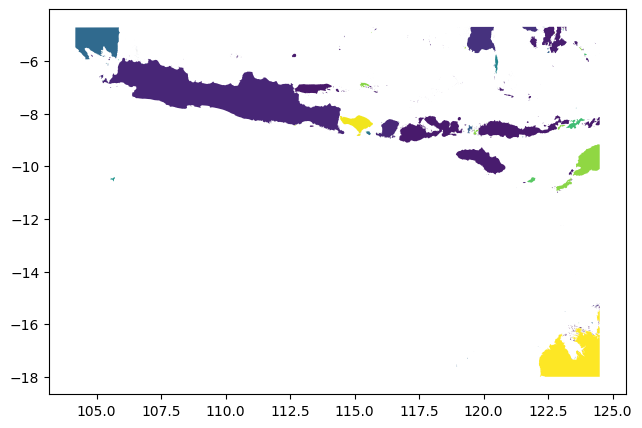

In [ ]:
gdf_kab = gpd.read_file("/OSM_JawaFloresAus_polygon.shp")
gdf_kab.head()
fig, ax = plt.subplots(figsize=(8,5))
gdf_kab.plot(ax=ax, column='FID_1')
plt.show()

In [ ]:
turb_vis3 = {
    'min': 0,
    'max': 3.5,
    'palette':cm.get_palette('copper_r')
}

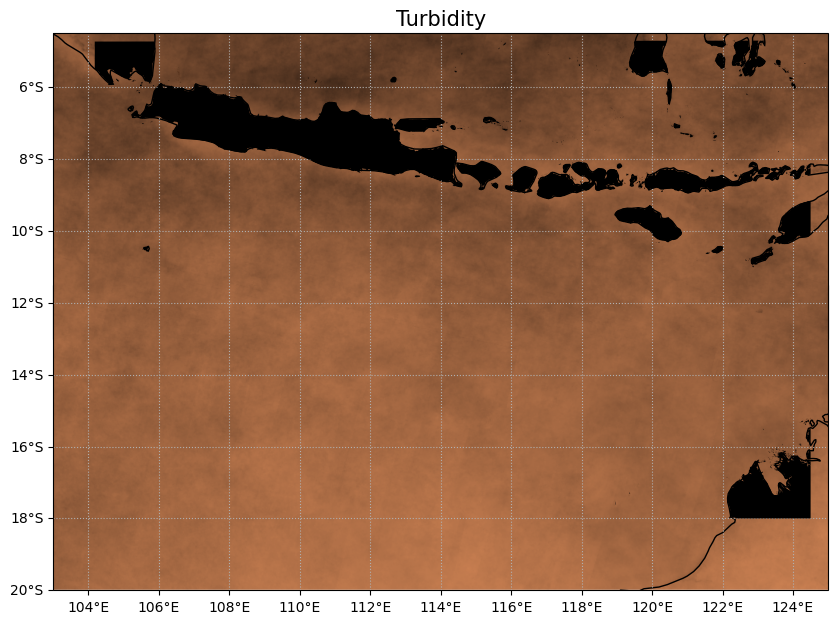

In [ ]:
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

zoom_region = [124, -17,
               104, -5]
ax.set_extent(zoom_region)

ax = cartoee.get_map(present_turb_clipped, vis_params = turb_vis3)
gdf_kab.plot(ax=ax, color='black', zorder=3)

cartoee.add_gridlines(ax, interval=2, linestyle=":")
ax.coastlines(color='black')
ax.set_title(label="Turbidity", fontsize=15)
plt.show()